# Car Price Prediction Project Modeling
This project aims to build and evaluate machine learning models for predicting used car prices. The pipeline is structured into the following key steps:

1.  **Advanced Data Cleaning**: Initial processing of raw car data to remove outliers, handle missing values, and prepare the target variable ('price') through logarithmic transformation for better model performance. We also compute a 'vehicle age' feature.
2.  **Indicator Engineering**: Creation of several categorical indicator features based on vehicle characteristics and listing titles (e.g., luxury brands, power features, utility keywords) to enrich the dataset.
3.  **Feature Pipeline**: Transformation of raw and engineered features into a format suitable for machine learning models. This involves Target Encoding for high-cardinality categorical features, One-Hot Encoding for low-cardinality features, and handling numerical data. All features are then stacked into sparse matrices.
4.  **Model Comparison**: Definition and instantiation of various regression models, including linear models (Lasso, Ridge), tree-based models (Decision Tree, Random Forest), and gradient boosting machines (XGBoost, CatBoost).
5.  **Execution & Results**: Training and evaluation of all defined models using the prepared dataset. Performance is measured using Root Mean Squared Error (RMSE), Mean Absolute Error (MAE), and Mean Absolute Percentage Error (MAPE).

The primary objective of this project is to minimize the prediction error, specifically targeting the **Mean Absolute Error (MAE)**. A lower MAE indicates a more accurate model in predicting car prices. The secondary objective is to evaluate the **Mean Absolute Percentage Error (MAPE)** to understand the average percentage deviation of predictions from actual prices, providing a more intuitive measure of accuracy from a business perspective. We aim to identify the model that achieves the lowest RMSE and MAPE on the test set while maintaining reasonable training and prediction times.

#0.0 Importing necessary libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import time
import warnings
from sklearn.linear_model import Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
import category_encoders as ce 
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import OneHotEncoder, TargetEncoder
from scipy.sparse import hstack, csr_matrix
from lightgbm import LGBMRegressor

warnings.filterwarnings('ignore')

print("Libraries installed successfully!")

Libraries installed successfully!


# 1. Loading the proper dataset


#### After running the AI_agent.py the script returns the dataset with the proper information needed to run the feature engineering pipeline. Also, a log transformation in the price column is made as well as dropping null values

In [3]:
df = pd.read_csv("data/cleaned_car_dataset_final.csv")


# Target Log Transform due to the righ-skewed distribution in the target variable
df["log_price"] = np.log1p(df["price"])

print("Data cleaning completed successfully!")

Data cleaning completed successfully!


In [4]:
df.isnull().sum()

marketplace_listing_title       0
vehicle_exterior_color          0
vehicle_fuel_type               0
vehicle_make_display_name       0
vehicle_transmission_type       0
kms                             0
price                           0
state                           0
year                            0
vehicle_model_display_name_0    0
performance_metrics             0
luxury                          0
size                            0
body_style                      0
drivetrain                      0
vehicle_model_display_name      0
description                     0
log_price                       0
dtype: int64

In [5]:
counts = df[['drivetrain']].value_counts()
print(counts)

drivetrain
FWD           3149
4WD           2190
AWD           1782
RWD           1184
quattro          1
Name: count, dtype: int64


In [6]:
#Cleaning 'quattro'
df.loc[df['drivetrain'] == 'quattro', 'drivetrain'] = '4WD'


counts = df[['drivetrain']].value_counts()
print(counts)

drivetrain
FWD           3149
4WD           2191
AWD           1782
RWD           1184
Name: count, dtype: int64


# 2. Splitting data In Features and Target

Here, we select the proper features for feature engineering

In [7]:
df[['vehicle_make_display_name', 'vehicle_model_display_name', 'performance_metrics', 'size', 'luxury', 'body_style','drivetrain']].head(10)

,vehicle_make_display_name,vehicle_model_display_name,performance_metrics,size,luxury,body_style,drivetrain
0,TOYOTA,CAMRY,3.0,3.0,2.5,Sedan,FWD
1,ISUZU,D-MAX,3.5,4.0,2.5,Dual-Cab UTE,4WD
2,FORD,RANGER,3.5,4.0,2.5,Dual-Cab UTE,4WD
3,TOYOTA,COROLLA,2.5,2.0,2.5,Hatchback,FWD
4,HOLDEN,UTE,3.0,4.0,2.0,UTE,RWD
5,VOLKSWAGEN,SCIROCCO,4.0,2.0,3.5,Liftback,FWD
6,TOYOTA,YARIS,2.5,1.5,2.5,Hatchback,FWD
7,JEEP,COMPASS,2.5,2.0,2.0,Compact SUV,FWD
8,NISSAN,X-TRAIL,3.0,3.0,2.5,SUV,4WD
9,SUBARU,FORESTER,3.0,3.0,3.0,SUV,AWD


In [8]:

#Since 'marketplace_listing_title' is only the merge of diff columns, keeping it is redundant.
#The price column is not necessary anymore since the log_price is already calculated.
#Other columns like 'vehicle_model_display_name_0' and 'description' are no longer necessary
cols_to_remove = ["marketplace_listing_title","price","vehicle_model_display_name_0",'description']
df.drop(cols_to_remove,axis=1,inplace=True)

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8306 entries, 0 to 8305
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   vehicle_exterior_color      8306 non-null   object 
 1   vehicle_fuel_type           8306 non-null   object 
 2   vehicle_make_display_name   8306 non-null   object 
 3   vehicle_transmission_type   8306 non-null   object 
 4   kms                         8306 non-null   int64  
 5   state                       8306 non-null   object 
 6   year                        8306 non-null   int64  
 7   performance_metrics         8306 non-null   float64
 8   luxury                      8306 non-null   float64
 9   size                        8306 non-null   float64
 10  body_style                  8306 non-null   object 
 11  drivetrain                  8306 non-null   object 
 12  vehicle_model_display_name  8306 non-null   object 
 13  log_price                   8306 

In [9]:
#Splitting data in Features and Target
X_features = df.drop('log_price', axis=1)
Y = df['log_price']

#Splitting in training and test sets
x_train_raw,x_test_raw,y_train,y_test = train_test_split(X_features,Y,train_size=.8,random_state=42)

print("X_train shape:", x_train_raw.shape,"X_test shape: ",x_test_raw.shape,
      "Y train shape:",y_train.shape, "Y test shape:", y_test.shape)

X_train shape: (6644, 13) X_test shape:  (1662, 13) Y train shape: (6644,) Y test shape: (1662,)


# 3. Feature Pipeline

3.1 Feature encoding

This section sets up the feature engineering pipeline. It categorizes columns for Target Encoding (high cardinality) and One-Hot Encoding (low cardinality), splits the dataset into training and testing sets, applies the respective encoders, processes numerical features, and finally stacks all processed features into sparse matrices (`X_train`, `X_test`) ready for model training.

In [10]:
# 1. Define column groups
cat_ohe_cols = ['state', 'vehicle_transmission_type','vehicle_fuel_type','drivetrain']   
cat_target_cols = ['vehicle_make_display_name', 'vehicle_model_display_name',
                   'vehicle_exterior_color', 'body_style'] 
num_cols = ['year', 'kms','size', 'performance_metrics','luxury']

# 2. Define pipelines
# Pipeline for numerical: Impute missing -> Scale
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', MinMaxScaler())
])

# Pipeline for OneHot: Impute -> Encode
ohe_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

# Pipeline for Target Encoding: Impute -> Encode
# TargetEncoder handles new categories in test data automatically
target_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', ce.TargetEncoder()),
    ('scaler',MinMaxScaler()) 
])

# 3. Combine into a preprocessor
preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipe, num_cols),
    ('ohe', ohe_pipe, cat_ohe_cols),
    ('target', target_pipe, cat_target_cols)
], remainder='drop')

# 4. Apply

# Fit only on TRAIN, transform TRAIN AND TEST
x_train = preprocessor.fit_transform(x_train_raw, y_train)
x_test = preprocessor.transform(x_test_raw)

print("Pipeline complete. Shapes:", x_train.shape, x_test.shape)

feature_names = preprocessor.get_feature_names_out()

target_mapping = {
    f'target__{i}': f'target__{col}' 
    for i, col in enumerate(cat_target_cols)
}

# Apply mapping
feature_names_readable = [
    target_mapping.get(name, name) for name in feature_names
]

print(feature_names_readable)

Pipeline complete. Shapes: (6644, 21) (1662, 21)
['num__year', 'num__kms', 'num__size', 'num__performance_metrics', 'num__luxury', 'ohe__state_QLD', 'ohe__state_SA', 'ohe__state_VIC', 'ohe__state_WA', 'ohe__vehicle_transmission_type_MANUAL', 'ohe__vehicle_fuel_type_ELECTRIC', 'ohe__vehicle_fuel_type_HYBRID', 'ohe__vehicle_fuel_type_OTHER', 'ohe__vehicle_fuel_type_PETROL', 'ohe__drivetrain_AWD', 'ohe__drivetrain_FWD', 'ohe__drivetrain_RWD', 'target__vehicle_make_display_name', 'target__vehicle_model_display_name', 'target__vehicle_exterior_color', 'target__body_style']


# 4. Model Comparison

#### This Section set up a baseline model based on the mean of the predicted values. We'll compare the mean of the train values and the test values and then calculate MAE

In [18]:
#baseline model
from sklearn.metrics import mean_absolute_error

mean_train_data = y_train.mean()

array_mean_model = [np.exp(mean_train_data)]*len(y_test)

MAE_baseline = mean_absolute_error(array_mean_model,y_test)
y_test_actual = np.exp(y_test)  
MAPE_baseline = np.mean(np.abs((y_test_actual - array_mean_model) / y_test_actual)) * 100
#RMSE_baseline = np.sqrt(mean_squared_error(y_test,array_mean_model))
print(f'The Mean Absolute Error of the baseline model is ', MAE_baseline)
print(f'The MAPE model is ', MAPE_baseline, '%')
print(f'The goal is to minimize this value by running a propper model.')

The Mean Absolute Error of the baseline model is  13151.562918359446
The MAPE model is  81.17517556041928 %
The goal is to minimize this value by running a propper model.


This block defines a dictionary named `models` containing various regression algorithms that will be used for comparative benchmarking. Each model is instantiated with specific hyperparameters, including linear models (Lasso, Ridge), tree-based models (Decision Tree, Random Forest), and gradient boosting machines (XGBoost, CatBoost), with early stopping configured for the boosting models.

In [119]:
models = {
    "Lasso (L1)": Lasso(alpha=0.01),
    "Ridge (L2)": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(max_depth=10, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=200, max_depth=12, n_jobs=-1, random_state=42),
    "lightXGBoost": LGBMRegressor(n_estimators=200,learning_rate=0.1,random_state=42),
    "XGBoost": XGBRegressor(n_estimators=1000, learning_rate=0.05, max_depth=6, n_jobs=-1, random_state=42, early_stopping_rounds=50),
    "CatBoost": CatBoostRegressor(iterations=1000, learning_rate=0.05, depth=6, verbose=0, random_seed=42, early_stopping_rounds=50,allow_writing_files=False)
}

print("Models defined successfully!")


Models defined successfully!


# 5. Execution & Results

In this section, a comparative benchmark is performed across all defined models. Each model is trained on the prepared data, and predictions are made on the test set. Performance metrics, including Root Mean Squared Error (RMSE), Mean Absolute Error (MAE), and Mean Absolute Percentage Error (MAPE), are calculated for the real (untransformed) price values. Finally, a leaderboard table summarizing the performance of all models is printed.

In [120]:
results = []
print("\n--- Starting Comparative Benchmark ---")

for name, model in models.items():
    start = time.time()

    if name in ["XGBoost", "CatBoost"]:
        # early_stopping_rounds moved to model constructor
        model.fit(x_train, y_train, eval_set=[(x_test, y_test)], verbose=False)
    else:
        model.fit(x_train, y_train)

    # Predictions
    p_log = model.predict(x_test)
    p_real = np.expm1(p_log)
    a_real = np.expm1(y_test.values)

    rmse = np.sqrt(mean_squared_error(a_real, p_real))
    mae = mean_absolute_error(a_real, p_real)
    mape = np.mean(np.abs((a_real - p_real) / a_real)) * 100

    print(f"Finished {name:15} | RMSE: ${rmse:,.0f} | MAPE: {mape:.1f}%")
    results.append({"Model": name, "RMSE": rmse, "MAE": mae, "MAPE %": mape})

# Final Table
results_df = pd.DataFrame(results).sort_values("RMSE")
print("\n=== FINAL LEADERBOARD ===")
print(results_df.to_string(index=False))


--- Starting Comparative Benchmark ---
Finished Lasso (L1)      | RMSE: $13,113 | MAPE: 38.3%
Finished Ridge (L2)      | RMSE: $11,651 | MAPE: 36.0%
Finished Decision Tree   | RMSE: $11,728 | MAPE: 37.7%
Finished Random Forest   | RMSE: $9,754 | MAPE: 29.7%
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000786 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 640
[LightGBM] [Info] Number of data points in the train set: 6644, number of used features: 20
[LightGBM] [Info] Start training from score 9.485017
Finished lightXGBoost    | RMSE: $9,795 | MAPE: 28.3%
Finished XGBoost         | RMSE: $9,606 | MAPE: 28.4%
Finished CatBoost        | RMSE: $9,966 | MAPE: 28.1%

=== FINAL LEADERBOARD ===
        Model         RMSE         MAE    MAPE %
      XGBoost  9606.231300 4560.281924 28.446253
Random Forest  9754.348509 4733.962258 29.665825
 lightXGBoost  9795.449310 4646.484060 28.341480
     CatBoost

According to the above results, CatBoost, XGBoost and LightXGBoost look like the best models in terms of error. Now, the next step is to fine tune these models and choose the best one based on RMSE, MAE and MAPE

In [22]:
#Tunning CatBoost Model
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

# Define parameter distributions
param_distributions = {
    'iterations': randint(500, 1500),
    'learning_rate': uniform(0.01, 0.2),
    'depth': randint(4, 12),
    'l2_leaf_reg': randint(1, 10),
    'min_data_in_leaf': randint(1, 30),
    'subsample': uniform(0.6, 0.4),
    'colsample_bylevel': uniform(0.6, 0.4)
}

catboost_base = CatBoostRegressor(
    loss_function='MAPE',
    random_seed=42,
    verbose=0,
    allow_writing_files=False,
    early_stopping_rounds=50
)

random_search = RandomizedSearchCV(
    estimator=catboost_base,
    param_distributions=param_distributions,
    n_iter=50, 
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=2,
    random_state=42
)

random_search.fit(x_train, y_train, eval_set=[(x_test, y_test)])

print("Best Parameters:", random_search.best_params_)
best_catboost = random_search.best_estimator_


# Predictions
p_log = best_catboost.predict(x_test)
p_real = np.expm1(p_log)
a_real = np.expm1(y_test.values)

# Metrics
rmse = np.sqrt(mean_squared_error(a_real, p_real))
mae = mean_absolute_error(a_real, p_real)
mape = np.mean(np.abs((a_real - p_real) / a_real)) * 100

print(f"\n🎯 TUNED CATBOOST RESULTS:")
print(f"RMSE: ${rmse:,.0f}")
print(f"MAE: ${mae:,.0f}")
print(f"MAPE: {mape:.2f}%")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters: {'colsample_bylevel': 0.7300733288106989, 'depth': 6, 'iterations': 1183, 'l2_leaf_reg': 8, 'learning_rate': 0.06494435859801283, 'min_data_in_leaf': 3, 'subsample': 0.7888859700647797}

🎯 TUNED CATBOOST RESULTS:
RMSE: $9,745
MAE: $4,489
MAPE: 27.70%


## Fine tunning XGBoost

In [ ]:
#Fine tune here

## Fine tunning LightXGBoost

In [ ]:
#Fine tune here

## Analyzing the feature importances

In [ ]:
############This is the analysis of all the features, please, after you choose the best model, 
# replace the model with the proper one to see the diagram the the feature importance from the best model found.

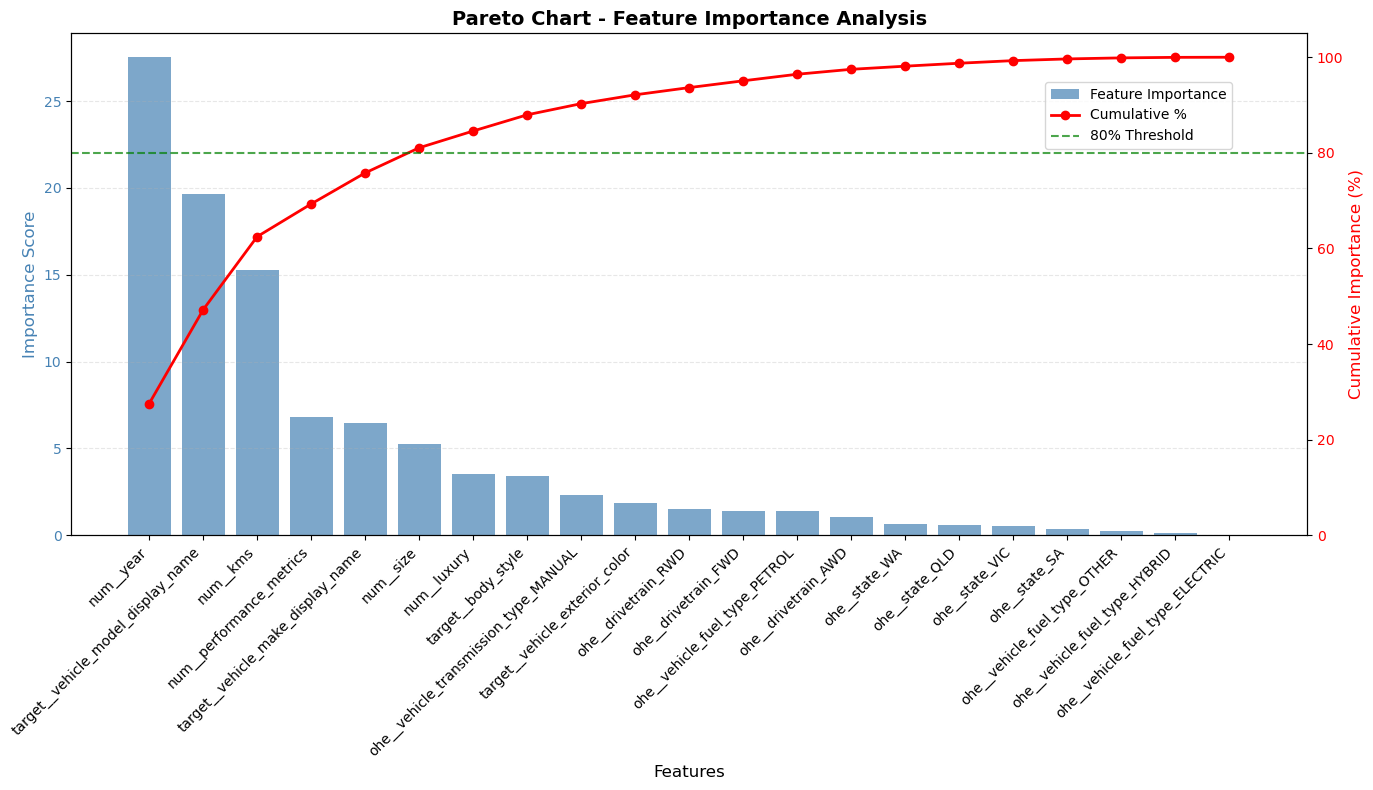


=== CUMULATIVE IMPORTANCE ANALYSIS ===
Top 5 features account for 75.8% of total importance
Top 10 features account for 92.1% of total importance
Top 15 features account for 98.1% of total importance
Top 20 features account for 100.0% of total importance


In [24]:
#Pareto!
# Get feature importances
importances = pd.Series(
    best_catboost.feature_importances_, ###### Replace the best model here
    index=feature_names_readable
).sort_values(ascending=False)

importances_sorted = importances.sort_values(ascending=False)

# Calculate cumulative percentage
cumulative_importance = np.cumsum(importances_sorted.values)
cumulative_percentage = (cumulative_importance / cumulative_importance[-1]) * 100

# Create figure with dual y-axes
fig, ax1 = plt.subplots(figsize=(14, 8))

# Bar chart for importances
x_pos = np.arange(len(importances_sorted))  
bars = ax1.bar(x_pos, importances_sorted.values, 
               color='steelblue', alpha=0.7, label='Feature Importance')

ax1.set_xlabel('Features', fontsize=12)
ax1.set_ylabel('Importance Score', fontsize=12, color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(importances_sorted.index, rotation=45, ha='right')

# Line chart for cumulative percentage
ax2 = ax1.twinx()
line = ax2.plot(x_pos, cumulative_percentage, 
                color='red', marker='o', linewidth=2, 
                markersize=6, label='Cumulative %')

ax2.set_ylabel('Cumulative Importance (%)', fontsize=12, color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim([0, 105])

# Add horizontal line at 80%
ax2.axhline(y=80, color='green', linestyle='--', linewidth=1.5, 
            label='80% Threshold', alpha=0.7)

# Add grid
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# Title and legends
plt.title('Pareto Chart - Feature Importance Analysis', fontsize=14, fontweight='bold')
fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.9))

plt.tight_layout()
plt.show()

# Print cumulative analysis
print("\n=== CUMULATIVE IMPORTANCE ANALYSIS ===")
for i in [5, 10, 15, 20]:
    if i <= len(cumulative_percentage):
        print(f"Top {i} features account for {cumulative_percentage[i-1]:.1f}% of total importance")


## Analyzing the error from catboost model

In [27]:
#######################
#Same, please replace your best model found so we can perform errors analysis better.

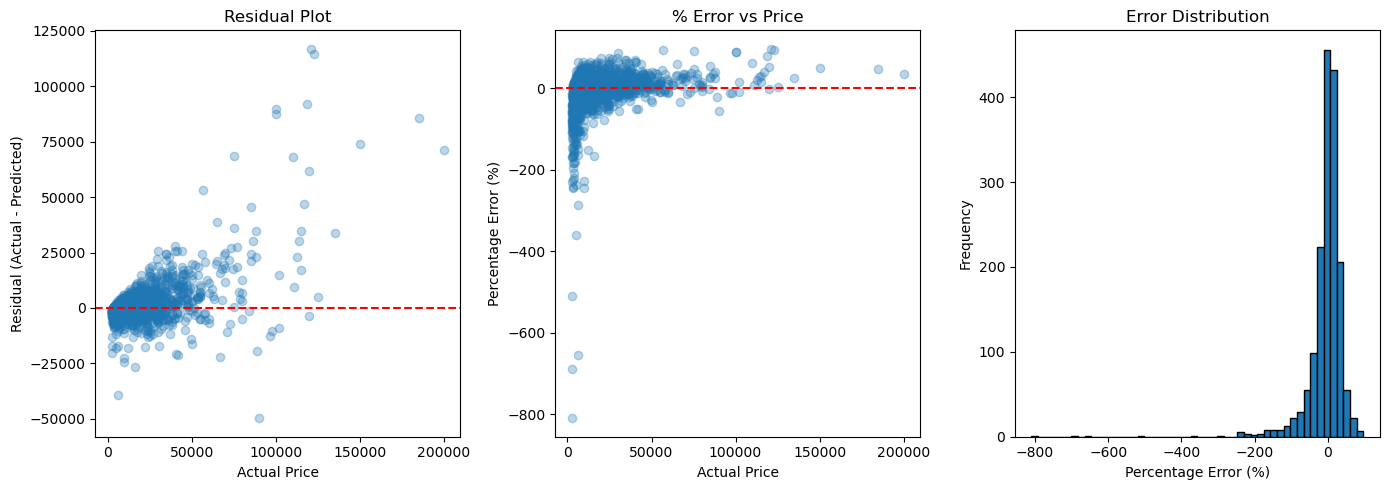


=== ERROR ANALYSIS BY PRICE SEGMENT ===
Cheap        | MAPE: 48.4% | MAE: $2,038
Mid-Low      | MAPE: 22.0% | MAE: $2,140
Mid-High     | MAPE: 18.4% | MAE: $3,249
Expensive    | MAPE: 21.7% | MAE: $10,540


In [ ]:
# Calculate residuals
p_log = best_catboost.predict(x_test)     # <----- Replace the model here.
p_real = np.expm1(p_log)
a_real = np.expm1(y_test.values)

residuals = a_real - p_real
percentage_errors = ((a_real - p_real) / a_real) * 100

# Plot residuals vs actual price
plt.figure(figsize=(14, 5))

plt.subplot(1, 3, 1)
plt.scatter(a_real, residuals, alpha=0.3)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Actual Price')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('Residual Plot')

plt.subplot(1, 3, 2)
plt.scatter(a_real, percentage_errors, alpha=0.3)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Actual Price')
plt.ylabel('Percentage Error (%)')
plt.title('% Error vs Price')

plt.subplot(1, 3, 3)
plt.hist(percentage_errors, bins=50, edgecolor='black')
plt.xlabel('Percentage Error (%)')
plt.ylabel('Frequency')
plt.title('Error Distribution')
plt.tight_layout()
plt.show()

# Segment analysis
print("\n=== ERROR ANALYSIS BY PRICE SEGMENT ===")
price_segments = pd.qcut(a_real, q=4, labels=['Cheap', 'Mid-Low', 'Mid-High', 'Expensive'])
for segment in ['Cheap', 'Mid-Low', 'Mid-High', 'Expensive']:
    mask = price_segments == segment
    segment_mape = np.mean(np.abs(percentage_errors[mask]))
    segment_mae = np.mean(np.abs(residuals[mask]))
    print(f"{segment:12} | MAPE: {segment_mape:.1f}% | MAE: ${segment_mae:,.0f}")

## The next code is simply testing the model. You can do that by editing the `input_vector` as you like. Play with this and see how good or bad a vehicle price is predicted. 

In [26]:
def predicting(input_vector):
    input_df = pd.DataFrame(input_vector,columns =
                            ['state', 'vehicle_transmission_type','vehicle_fuel_type','drivetrain',
                             'vehicle_make_display_name', 'vehicle_model_display_name',
                             'vehicle_exterior_color', 'body_style',
                             'year', 'kms', 'performance_metrics','luxury', 'size'])
    transformed_input_vector = preprocessor.transform(input_df)
    y_pred_output = best_catboost.predict(transformed_input_vector)
    return y_pred_output

input_vector = [['VIC', 'AUTOMATIC', 'PETROL', 'FWD', 'TOYOTA', 'YARIS', 'WHITE',
                 'Hatchback',2008,200000,2,2,1 ]]

predicted_price = np.exp(predicting(input_vector))
print(predicted_price)
                        
#2016 Toyota Corolla,red,PETROL,TOYOTA,AUTOMATIC,94627,16800,VIC,2016,Corolla,2.5,2.5,2,Hatchback,FWD,COROLLA


[5991.00279489]


In [ ]:
df['price'] = np.exp(df['log_price'])
df[(df['vehicle_model_display_name'] == 'YARIS') & (df['year'] == 2008)]

,vehicle_exterior_color,vehicle_fuel_type,vehicle_make_display_name,vehicle_transmission_type,kms,state,year,performance_metrics,luxury,size,body_style,drivetrain,vehicle_model_display_name,log_price,price
128,silver,PETROL,TOYOTA,AUTOMATIC,144000,VIC,2008,2.0,2.0,1.0,Hatchback,FWD,YARIS,8.699681,6001.0
169,black,PETROL,TOYOTA,AUTOMATIC,80712,NSW,2008,2.0,2.0,1.0,Hatchback,FWD,YARIS,9.047939,8501.0
190,black,PETROL,TOYOTA,MANUAL,236000,NSW,2008,2.0,2.0,1.0,Hatchback,FWD,YARIS,7.937732,2801.0
346,silver,OTHER,TOYOTA,AUTOMATIC,245000,QLD,2008,2.0,2.0,1.0,Hatchback,FWD,YARIS,8.160804,3501.0
658,green,PETROL,TOYOTA,AUTOMATIC,272325,WA,2008,2.0,2.0,1.0,Hatchback,FWD,YARIS,8.188967,3601.0
1778,red,PETROL,TOYOTA,AUTOMATIC,181000,NSW,2008,2.0,2.0,1.0,Hatchback,FWD,YARIS,8.071219,3201.0
2160,white,PETROL,TOYOTA,MANUAL,300,QLD,2008,2.0,2.0,1.0,Hatchback,FWD,YARIS,8.294300,4001.0
2165,black,OTHER,TOYOTA,MANUAL,300000,QLD,2008,2.0,2.0,1.0,Hatchback,FWD,YARIS,8.412055,4501.0
2518,silver,PETROL,TOYOTA,AUTOMATIC,255000,VIC,2008,2.0,2.0,1.0,Hatchback,FWD,YARIS,8.556606,5201.0
4706,yellow,PETROL,TOYOTA,MANUAL,185000,QLD,2008,2.0,2.0,1.0,Hatchback,FWD,YARIS,8.612685,5501.0
